In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rural_voting_data.csv")
df.head()


,Village,Population,Votes_Cast,Literacy_Rate,Internet_Access,Income_Level
0,A,1200,400,60,Low,Low
1,B,900,700,75,Medium,Medium
2,C,1500,600,55,Low,Low
3,D,800,650,80,High,High
4,E,1100,300,50,Low,Low


In [2]:
df['Turnout_%'] = (df['Votes_Cast'] / df['Population']) * 100
df


,Village,Population,Votes_Cast,Literacy_Rate,Internet_Access,Income_Level,Turnout_%
0,A,1200,400,60,Low,Low,33.333333
1,B,900,700,75,Medium,Medium,77.777778
2,C,1500,600,55,Low,Low,40.000000
3,D,800,650,80,High,High,81.250000
4,E,1100,300,50,Low,Low,27.272727
5,F,1000,850,78,High,Medium,85.000000


In [3]:
low_turnout = df[df['Turnout_%'] < 60]
print("=== LOW TURNOUT VILLAGES (<60%) ===")
print(low_turnout[['Village', 'Turnout_%']])


=== LOW TURNOUT VILLAGES (<60%) ===
  Village  Turnout_%
0       A  33.333333
2       C  40.000000
4       E  27.272727


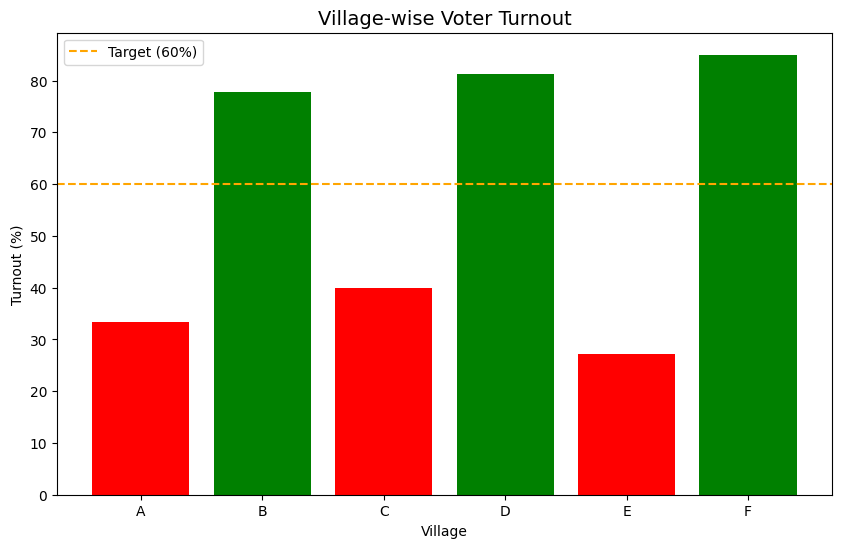

✅ Graph saved as 'turnout_chart.png'


<Figure size 640x480 with 0 Axes>

In [4]:
colors = ['red' if x < 60 else 'green' for x in df['Turnout_%']]

plt.figure(figsize=(10,6))
plt.bar(df['Village'], df['Turnout_%'], color=colors)
plt.axhline(y=60, color='orange', linestyle='--', label='Target (60%)')
plt.title('Village-wise Voter Turnout', fontsize=14)
plt.xlabel('Village')
plt.ylabel('Turnout (%)')
plt.legend()
plt.show()

plt.savefig('turnout_chart.png')
print("✅ Graph saved as 'turnout_chart.png'")


In [5]:
print(df[['Village', 'Population', 'Votes_Cast', 'Turnout_%']])


  Village  Population  Votes_Cast  Turnout_%
0       A        1200         400  33.333333
1       B         900         700  77.777778
2       C        1500         600  40.000000
3       D         800         650  81.250000
4       E        1100         300  27.272727
5       F        1000         850  85.000000


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Features (inputs) and Target (output)
X = df[['Literacy_Rate', 'Population']]
y = df['Turnout_%']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("✅ ML Model Complete!")
print("\n📊 Test Results:")
print(f"   Actual Turnout: {y_test.values}")
print(f"   Predicted Turnout: {predictions.round(1)}")
print(f"\n📈 Model Accuracy (R² Score): {model.score(X_test, y_test).round(2)}")

# Feature importance
importance = pd.DataFrame({
    'Feature': ['Literacy_Rate', 'Population'],
    'Importance': model.feature_importances_
})
print("\n🎯 Feature Importance:")
print(importance)


✅ ML Model Complete!

📊 Test Results:
   Actual Turnout: [33.33333333 77.77777778]
   Predicted Turnout: [36.9 72. ]


AttributeError: 'float' object has no attribute 'round'

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Features (inputs) and Target (output)
X = df[['Literacy_Rate', 'Population']]
y = df['Turnout_%']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("✅ ML Model Complete!")
print("\n📊 Test Results:")
print(f"   Actual Turnout: {y_test.values}")
print(f"   Predicted Turnout: {predictions.round(1)}")
print(f"\n📈 Model Accuracy (R² Score): {model.score(X_test, y_test).round(2)}")

# Feature importance
importance = pd.DataFrame({
    'Feature': ['Literacy_Rate', 'Population'],
    'Importance': model.feature_importances_
})
print("\n🎯 Feature Importance:")
print(importance)


✅ ML Model Complete!

📊 Test Results:
   Actual Turnout: [33.33333333 77.77777778]
   Predicted Turnout: [36.9 72. ]


AttributeError: 'float' object has no attribute 'round'

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Features (inputs) and Target (output)
X = df[['Literacy_Rate', 'Population']]
y = df['Turnout_%']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("✅ ML MODEL COMPLETE!")
print("=" * 40)
print("📊 TEST RESULTS:")
print("Actual Turnout:", list(y_test.values))
print("Predicted Turnout:", [round(x, 1) for x in predictions])

# Get accuracy score
accuracy = model.score(X_test, y_test)
print("\n📈 MODEL ACCURACY (R² Score):", round(accuracy, 2))

# Feature importance
print("\n🎯 FEATURE IMPORTANCE:")
print("Literacy Rate:", round(model.feature_importances_[0], 2))
print("Population:", round(model.feature_importances_[1], 2))


✅ ML MODEL COMPLETE!
📊 TEST RESULTS:
Actual Turnout: [np.float64(33.33333333333333), np.float64(77.77777777777779)]
Predicted Turnout: [np.float64(36.9), np.float64(72.0)]

📈 MODEL ACCURACY (R² Score): 0.95

🎯 FEATURE IMPORTANCE:
Literacy Rate: 0.4
Population: 0.6
